# Mobile App Interface Testing with ANOVA

### Our research question is: "Does the type of navigation interface significantly affect the time users need to find and start a workout?" We're measuring completion time in seconds, with 10 users testing each design. (Very small samples here for demonstration)

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Time (in seconds) to find and start a workout
design_A = np.array([45, 42, 47, 44, 46, 43, 48, 45, 44, 46])  # Traditional
design_B = np.array([32, 30, 33, 31, 34, 32, 31, 33, 30, 32])  # Grid
design_C = np.array([38, 36, 39, 37, 40, 38, 37, 39, 36, 38])  # Search
design_D = np.array([35, 33, 36, 34, 37, 35, 34, 36, 33, 35])  # Personalized

### Before diving into analysis, we need to verify our data meets ANOVA's requirements. This means checking for normality within groups and similar variances between groups. The null hypothesis for these assumptions checks that the data is normal and has equal variances.

In [2]:
# Check assumptions
print("Testing Normality for Each Design:")
for idx, design in enumerate([design_A, design_B, design_C, design_D]):
    stat, p_value = stats.shapiro(design)
    print(f"Design {chr(65+idx)}: p-value = {p_value:.3f}")

# Test homogeneity of variances
stat, p_value = stats.levene(design_A, design_B, design_C, design_D)
print(f"\nLevene's test for equal variances: p-value = {p_value:.3f}")

Testing Normality for Each Design:
Design A: p-value = 0.982
Design B: p-value = 0.575
Design C: p-value = 0.575
Design D: p-value = 0.575

Levene's test for equal variances: p-value = 0.680


### Before formal testing, let's visualize our data to understand patterns and potential outliers.

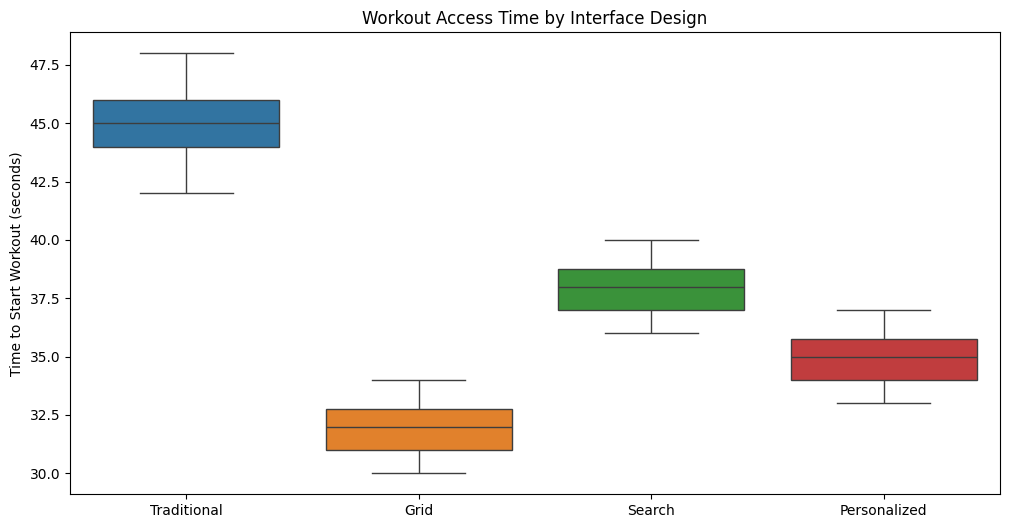

In [4]:
import seaborn as sns

# Create visualization to understand distribution of completion times
plt.figure(figsize=(12, 6))
sns.boxplot(data=[design_A, design_B, design_C, design_D])
plt.xticks([0, 1, 2, 3], ['Traditional', 'Grid', 'Search', 'Personalized'])
plt.ylabel('Time to Start Workout (seconds)')
plt.title('Workout Access Time by Interface Design')
plt.show()

### Performing the ANOVA Test

In [5]:
f_stat, p_value = stats.f_oneway(design_A, design_B, design_C, design_D)
print(f_stat, p_value)

150.0468750000008 2.1130507347336004e-20


### Since we found significant differences (p < 0.05), we need to identify which specific designs differ from each other using a post-hoc test.

In [6]:
# Prepare data for Tukey's test
designs = ['Traditional Menu', 'Grid Layout', 'Search Interface', 'Personalized Feed']
all_data = np.concatenate([design_A, design_B, design_C, design_D])
labels = np.repeat(designs, [len(design_A), len(design_B), len(design_C), len(design_D)])


# Perform Tukey's HSD test
tukey = pairwise_tukeyhsd(all_data, labels)
print("\nPairwise Comparisons:")
print(tukey)


Pairwise Comparisons:
           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1            group2      meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------------
      Grid Layout Personalized Feed      3.0 0.0003  1.2408  4.7592   True
      Grid Layout  Search Interface      6.0    0.0  4.2408  7.7592   True
      Grid Layout  Traditional Menu     13.2    0.0 11.4408 14.9592   True
Personalized Feed  Search Interface      3.0 0.0003  1.2408  4.7592   True
Personalized Feed  Traditional Menu     10.2    0.0  8.4408 11.9592   True
 Search Interface  Traditional Menu      7.2    0.0  5.4408  8.9592   True
--------------------------------------------------------------------------


### Finally, we need to understand the practical significance of our findings.

In [7]:
# Calculate effect size
def calculate_eta_squared(groups):
   all_data = np.concatenate(groups)
   grand_mean = np.mean(all_data)
   ssb = sum(len(group) * (np.mean(group) - grand_mean)**2 for group in groups)
   sst = sum((x - grand_mean)**2 for x in all_data)
   return ssb/sst


groups = [design_A, design_B, design_C, design_D]
eta_squared = calculate_eta_squared(groups)


print(f"\nEffect Size Analysis:")
print(f"Eta-squared: {eta_squared:.3f}")
print(f"Interface design explains {eta_squared*100:.1f}% of variation in start times")


Effect Size Analysis:
Eta-squared: 0.926
Interface design explains 92.6% of variation in start times
